# Evaluation - Comparing CGAN and Conditional Diffusion 

## Plan

1. Understand how to measure the quality and diversity of generated data using **FID**.  
2. Compare **cGAN vs Diffusion** outputs visually and statistically.  
3. Train a downstream **handwriting classifier** using synthetic data.  
4. Assess which generative approach produces more *useful* data for CAPTCHA robustness.



### Objectives to check
+ Do the samples look human like 
+ we would measure the quantititative quality using Frechet Inception Distance 
+ Also work on using sythetic data from each model to train a useful classifier

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from torchvision.models import inception_v3
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os, sys
from scipy import linalg


from utils.visualize import show_batch, plot_real_cgan_diffusion
from utils.checkpoint import load_checkpoint
from utils.metrics import compute_fid
from torchmetrics.image.fid import FrechetInceptionDistance

We’ll now load both trained models — the **cGAN** and **Diffusion** generators —  
and use them to generate a fixed number of samples for evaluation.

In [2]:
from model.cgan import Generator
from model.diffusion import ConditionalUNet
from training.train_diffusion import sample_images

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f" Using device: {device}")



 Using device: mps


In [3]:
# Helper Functions

from torchvision import datasets, transforms
def get_real_examples_per_class(n_classes=10):
    """
    Deterministically extracts one MNIST image per class (0–9)
    directly from the dataset without shuffle.
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    mnist = datasets.MNIST(root="../data", train=False, download=True, transform=transform)

    imgs, labels = [], []
    for cls in range(n_classes):
        for i in range(len(mnist)):
            if mnist[i][1] == cls:
                imgs.append(mnist[i][0])
                labels.append(cls)
                break  # stop at first match
    return torch.stack(imgs), torch.tensor(labels)




def get_representative_images(imgs, labels, n_classes=10):
    """
    Returns one representative image per class label (0–9).
    Ensures true label alignment for real datasets.
    """
    reps = []
    for i in range(n_classes):
        idx = (labels == i).nonzero(as_tuple=True)[0]
        if len(idx) > 0:
            reps.append(imgs[idx[0]])
        else:
            reps.append(torch.zeros_like(imgs[0]))  
    return torch.stack(reps)


@torch.no_grad()
def generate_conditioned_samples_cgan(generator, z_dim=100, device="cuda", n_classes=10, n_samples=None):
    """
    Generate one representative sample per class (0–9) from cGAN.
    """
    generator.eval()
    n_samples = n_classes if n_samples is None else n_samples
    zs = torch.randn(n_samples, z_dim, device=device)
    ys = torch.arange(n_samples, dtype=torch.long, device=device) % n_classes
    imgs = generator(zs, ys).cpu()
    return imgs, ys.cpu()


@torch.no_grad()
def generate_conditioned_samples_diffusion(
    model,
    device="cuda",
    n_classes=10,
    n_samples=None,
    timesteps=200,          # used same as training
    img_size=(1, 28, 28),
    batch_size=100,
):
    """
    Generate one representative diffusion sample per class (0–9), 
    using the same sampling logic as training-time generation.
    """
    n_samples = n_classes if n_samples is None else n_samples
    all_imgs, all_labels = [], []
    for start in range(0, n_samples, batch_size):
        count = min(batch_size, n_samples - start)
        labels = torch.arange(start, start + count, device=device) % n_classes
        imgs, labels = sample_images(
            model, device, num_samples=count, num_classes=n_classes,
            img_size=img_size, timesteps=timesteps, class_labels=labels,
        )
        all_imgs.append(imgs.cpu())
        all_labels.append(labels.cpu())
    return torch.cat(all_imgs), torch.cat(all_labels)


def plot_real_cgan_diffusion(real_imgs, cgan_imgs, diff_imgs, n_classes=10):
    """
    Visual comparison between Real, cGAN, and Diffusion images.
   
    """

    fig, axs = plt.subplots(3, n_classes, figsize=(12, 4))
    fig.suptitle(" Comparison: Real vs cGAN vs Diffusion", fontsize=14, fontweight="bold")

    row_titles = [
        "Ground Truth",
        "CGAN",
        "Diffusion"
    ]
    row_colors = ["green", "royalblue", "darkorange"]

    # Plot each row
    for row_idx, row_imgs in enumerate([real_imgs, cgan_imgs, diff_imgs]):
        for i in range(n_classes):
            axs[row_idx, i].imshow(row_imgs[i].squeeze(), cmap="gray")
            axs[row_idx, i].axis("off")
            axs[row_idx, i].set_title(f"Class {i}", fontsize=8, pad=2)

    # Manually place row labels on figure (not as axis labels)
    for idx, (title, color) in enumerate(zip(row_titles, row_colors)):
        fig.text(
            0.02,                                   # x-position (left margin)
            0.84 - idx * 0.32,                      # y-position per row
            title,
            fontsize=11,
            color=color,
            fontweight="bold",
            va="center"
        )

    plt.subplots_adjust(left=0.12, right=0.98, top=0.9, bottom=0.05, hspace=0.3)
    plt.show()

In [4]:


def compute_fid_legacy(real_imgs, fake_imgs, device="cuda", batch_size=128):
    """
    Compute FID safely in GPU batches to prevent OOM.
    Works with TorchMetrics' FrechetInceptionDistance.
    """
    fid = FrechetInceptionDistance(normalize=True).to(device)
    fid.reset()

    def batched_update(imgs, real_flag):
        for i in tqdm(range(0, imgs.size(0), batch_size), desc=f"FID {'real' if real_flag else 'fake'}"):
            batch = imgs[i:i + batch_size].to(device, non_blocking=True)
            fid.update(batch, real=real_flag)
            torch.cuda.empty_cache()


    real_imgs_rgb = (real_imgs.repeat(1, 3, 1, 1) + 1) / 2
    fake_imgs_rgb = (fake_imgs.repeat(1, 3, 1, 1) + 1) / 2
    real_imgs_rgb = torch.clamp(real_imgs_rgb, 0, 1)
    fake_imgs_rgb = torch.clamp(fake_imgs_rgb, 0, 1)

    batched_update(real_imgs_rgb, real_flag=True)
    batched_update(fake_imgs_rgb, real_flag=False)

    score = fid.compute().item()
    return score

In [5]:
# Safety clean up
torch.cuda.empty_cache()

In [6]:
# Load trained checkpoints (adjust path if different)
os.makedirs("../checkpoints", exist_ok=True)

cgan_gen = Generator(z_dim=100, num_classes=10).to(device)
diff_model = ConditionalUNet(num_classes=10).to(device)
# Load latest checkpoints
load_checkpoint(cgan_gen, path="../checkpoints/cgan_generator_epochfinal.pt", map_location=device)
load_checkpoint(diff_model, path="../checkpoints/diffusion_unet_epochfinal.pt", map_location=device)

cgan_gen.eval()
diff_model.eval()

Loaded model weights from ../checkpoints/cgan_generator_epochfinal.pt
Loaded model weights from ../checkpoints/diffusion_unet_epochfinal.pt


ConditionalUNet(
  (time_mlp): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (down1): ResidualBlock(
    (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (time_emb): Linear(in_features=128, out_features=64, bias=True)
    (label_emb): Embedding(10, 64)
    (shortcut): Conv2d(1, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (down2): ResidualBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 128, eps=1e-05, affine=True, bias=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 128, eps=1e-05, affine=True, bias=True)
    (time

In [7]:


real_imgs, real_labels = get_real_examples_per_class()
cgan_display, cgan_display_labels = generate_conditioned_samples_cgan(cgan_gen, device=device)
diff_display, diff_display_labels = generate_conditioned_samples_diffusion(diff_model, device=device)

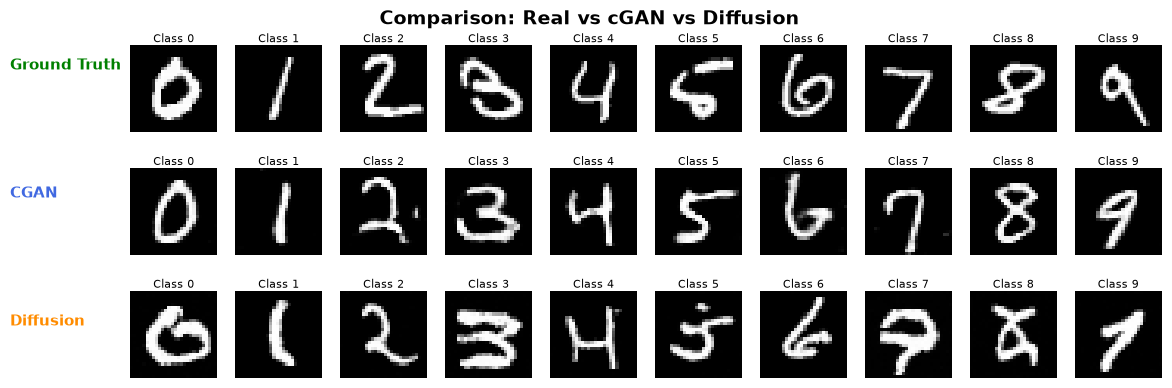

In [8]:
plot_real_cgan_diffusion(real_imgs, cgan_display, diff_display)

In [9]:
# Use a balanced evaluation set. Increase this for a more reliable final report.
num_eval_samples = 1000

In [10]:
torch.cuda.empty_cache()

In [11]:
eval_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
real_dataset = datasets.MNIST(root="../data", train=False, download=True, transform=eval_transform)
real_subset = torch.stack([real_dataset[i][0] for i in range(num_eval_samples)])
cgan_subset, cgan_labels = generate_conditioned_samples_cgan(
    cgan_gen, device=device, n_samples=num_eval_samples
)
diff_subset, diff_labels = generate_conditioned_samples_diffusion(
    diff_model, device=device, n_samples=num_eval_samples, timesteps=200
)

In [12]:
cgan_fid = compute_fid(real_subset, cgan_subset, device=device)
diff_fid = compute_fid(real_subset, diff_subset, device=device)
print(f" cGAN FID: {cgan_fid:.2f}")
print(f"Diffusion FID: {diff_fid:.2f}")
fid_winner = "cGAN" if cgan_fid < diff_fid else "Diffusion"
print(f"{fid_winner} has the lower FID in this run.")

 cGAN FID: 22.87
Diffusion FID: 36.85
cGAN has the lower FID in this run.


### FID analysis

The **cGAN produced the higher-fidelity and more diverse samples by FID** in this run: its FID was **22.87**, lower than the Diffusion model's **36.85**. Both synthetic datasets were highly useful for the downstream task: the cGAN-trained classifier reached **90.5%** accuracy on real MNIST, while the Diffusion-trained classifier reached a slightly higher **91.2%**. Thus, cGAN leads on distributional similarity, while Diffusion has a small utility advantage. FID is an aggregate distribution metric rather than a per-image quality score, and its estimate becomes more reliable when `num_eval_samples` is increased.

### Utility Evaluation (Classifier)

We’ll train a simple CNN classifier on synthetic data from each model,  
then test it on real MNIST data.

If synthetic data are realistic and diverse, the classifier should generalize well to real digits.

In [13]:
cgan_imgs, cgan_labels = cgan_subset, cgan_labels
diff_imgs, diff_labels = diff_subset, diff_labels


In [14]:

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [15]:
real_data = datasets.MNIST(root="../data", train=False, download=True, transform=transform)

In [16]:
def normalize_synthetic(imgs):
    # Both generators already target [-1, 1], matching normalized MNIST.
    return imgs.float().clamp(-1, 1)

cgan_imgs = normalize_synthetic(cgan_imgs)
diff_imgs = normalize_synthetic(diff_imgs)

print("Unique labels in CGAN:", torch.unique(cgan_labels))
print("Unique labels in Diffusion:", torch.unique(diff_labels))

Unique labels in CGAN: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
Unique labels in Diffusion: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


In [17]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 7 * 7, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

def train_classifier(model, loader, epochs=3):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            loss = criterion(preds, labels)

            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}: loss = {total_loss / len(loader):.4f}")
    return model

In [18]:
cgan_ds = TensorDataset(cgan_imgs, cgan_labels)
diff_ds = TensorDataset(diff_imgs, diff_labels)


cgan_loader = DataLoader(cgan_ds, batch_size=128, shuffle=True)
diff_loader = DataLoader(diff_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(real_data, batch_size=256, shuffle=False)

def test_accuracy(model, loader):
    correct, total = 0, 0
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            correct += (preds.argmax(1) == labels).sum().item()
            total += len(labels)
    return correct / total

In [19]:

cnn_cgan = train_classifier(SimpleCNN().to(device), cgan_loader, epochs=20)
cnn_diff = train_classifier(SimpleCNN().to(device), diff_loader, epochs=20)

cgan_acc = test_accuracy(cnn_cgan, test_loader)
diff_acc = test_accuracy(cnn_diff, test_loader)

print(f"Classifier trained on cGAN data → Test accuracy: {cgan_acc:.3f}")
print(f"Classifier trained on Diffusion data → Test accuracy: {diff_acc:.3f}")

Epoch 1: loss = 2.2267
Epoch 2: loss = 1.2911


Epoch 3: loss = 0.3882
Epoch 4: loss = 0.1662
Epoch 5: loss = 0.0884


Epoch 6: loss = 0.0409
Epoch 7: loss = 0.0222
Epoch 8: loss = 0.0101
Epoch 9: loss = 0.0070


Epoch 10: loss = 0.0044
Epoch 11: loss = 0.0034
Epoch 12: loss = 0.0026
Epoch 13: loss = 0.0019


Epoch 14: loss = 0.0014
Epoch 15: loss = 0.0014
Epoch 16: loss = 0.0011
Epoch 17: loss = 0.0009


...

Epoch 9: loss = 0.6544
Epoch 10: loss = 0.5794
Epoch 11: loss = 0.5380


Epoch 12: loss = 0.4716
Epoch 13: loss = 0.4009
Epoch 14: loss = 0.3416


Epoch 15: loss = 0.3392
Epoch 16: loss = 0.3089
Epoch 17: loss = 0.2640


Epoch 18: loss = 0.2131
Epoch 19: loss = 0.2078
Epoch 20: loss = 0.1629


Classifier trained on cGAN data → Test accuracy: 0.905
Classifier trained on Diffusion data → Test accuracy: 0.912
